<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [ ]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [ ]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Lab 1: Generative AI for Data Preparation


Write a Python code that can perform the following tasks.
Read the CSV file, located on a given file path, into a Pandas data frame, assuming that the first rows of the file are the headers for the data.

In [1]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
# Python
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    """
    Read a CSV file into a Pandas DataFrame assuming the first row contains headers.

    Parameters:
        file_path (str): Absolute or relative path to the CSV file.

    Returns:
        pd.DataFrame: Loaded DataFrame.
    """
    df = pd.read_csv(file_path, header=0)
    return df

# Example usage:
# df = read_csv_to_dataframe("path/to/your/file.csv")
# print(df.head())

df = read_csv_to_dataframe("11_Generative_AI_laptop_pricing_dataset_mod1.csv")
df

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,233,Lenovo,4,IPS Panel,2,1,7,35.560,2.6,8,256,1.70,1891
234,234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.20,1950
235,235,Lenovo,4,IPS Panel,2,1,5,30.480,2.6,8,256,1.36,2236
236,236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.40,883


Write a Python code that identifies the columns with missing values in a pandas data frame.

In [2]:
# Python
import pandas as pd

def columns_with_missing(df: pd.DataFrame) -> pd.Series:
    """
    Return a boolean Series indicating which columns contain missing values.
    """
    return df.isna().any()

# Example usage:
# missing_cols_mask = columns_with_missing(df)
# cols_with_missing = missing_cols_mask[missing_cols_mask].index.tolist()
# print(cols_with_missing)

missing_cols_mask = columns_with_missing(df)
cols_with_missing = missing_cols_mask[missing_cols_mask].index.tolist()
print(cols_with_missing)

['Screen_Size_cm', 'Weight_kg']


Write a Python code to replace the missing values in a pandas data frame, per the following guidelines.
1. For a categorical attribute "Screen_Size_cm", replace the missing values with the most frequent value in the column.
2. For a continuous value attribute "Weight_kg", replace the missing values with the mean value of the entries in the column.

In [3]:
# Python
import pandas as pd

# Assuming df is your DataFrame
# 1) Categorical: fill Screen_Size_cm with its mode (most frequent value)
mode_val = df['Screen_Size_cm'].mode().iloc[0]
df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(mode_val)

# 2) Continuous: fill Weight_kg with its mean
mean_val = df['Weight_kg'].mean()
df['Weight_kg'] = df['Weight_kg'].fillna(mean_val)

# Optional: verify no NaNs remain in these columns
print(df[['Screen_Size_cm', 'Weight_kg']].isna().sum())

Screen_Size_cm    0
Weight_kg         0
dtype: int64


Write a Python code snippet to change the data type of the attributes "Screen_Size_cm" and "Weight_kg" of a data frame to float.

In [4]:
# Python
# Ensure the columns exist, then convert to float
df['Screen_Size_cm'] = df['Screen_Size_cm'].astype(float)
df['Weight_kg'] = df['Weight_kg'].astype(float)

# Optional: check dtypes
print(df[['Screen_Size_cm', 'Weight_kg']].dtypes)

Screen_Size_cm    float64
Weight_kg         float64
dtype: object


Write a Python code to modify the contents under the following attributes of the data frame as required.
1. Data under 'Screen_Size_cm' is assumed to be in centimeters. Convert this data into inches. Modify the name of the attribute to 'Screen_Size_inch'.
2. Data under 'Weight_kg' is assumed to be in kilograms. Convert this data into pounds. Modify the name of the attribute to 'Weight_pounds'.

In [5]:
# Python
# 1) Convert centimeters to inches and rename column
df['Screen_Size_inch'] = df['Screen_Size_cm'].astype(float) / 2.54
df = df.drop(columns=['Screen_Size_cm'])

# 2) Convert kilograms to pounds and rename column
df['Weight_pounds'] = df['Weight_kg'].astype(float) * 2.2046226218
df = df.drop(columns=['Weight_kg'])

# Optional: quick check
print(df[['Screen_Size_inch', 'Weight_pounds']].head())

   Screen_Size_inch  Weight_pounds
0              14.0       3.527396
1              15.6       4.850170
2              15.6       4.850170
3              13.3       2.689640
4              15.6       4.210829


Write a Python code to normalise the content under the attribute "CPU_frequency" in a data frame df concerning its maximum value. Make changes to the original data, and do not create a new attribute.

In [7]:
# Python
# Normalise CPU_frequency by its maximum value, in place
max_val = df['CPU_frequency'].max()
if pd.notna(max_val) and max_val != 0:
    df['CPU_frequency'] = df['CPU_frequency'] / max_val
else:
    # If max is NaN or 0, leave the column unchanged or handle as needed
    pass

Write a Python code to perform the following tasks.
1. Convert a data frame df attribute "Screen", into indicator variables, saved as df1, with the naming convention "Screen_<unique value of the attribute>".
2. Append df1 into the original data frame df.
3. Drop the original attribute from the data frame df.

In [9]:
# Python
# 1) One-hot encode "Screen" with prefix "Screen_" as df1
df1 = pd.get_dummies(df['Screen'], prefix='Screen')

# 2) Append df1 to original df
df = pd.concat([df, df1], axis=1)

# 3) Drop original "Screen" column
df = df.drop(columns=['Screen'])

In [10]:
df1

,Screen_Full HD,Screen_IPS Panel
0,False,True
1,True,False
2,True,False
3,False,True
4,True,False
...,...,...
233,False,True
234,True,False
235,False,True
236,True,False


## Practice problems

1. Create a prompt to generate a Python code that converts the values under Price from USD to Euros.

Write Python code that:
- Reads a CSV into a pandas DataFrame (variable name df).
- Assumes df has a numeric column named "Price" in USD.
- Converts "Price" from USD to EUR using a configurable exchange rate variable usd_to_eur (default 0.92).
- Creates a new column "Price_EUR" with values rounded to 2 decimals; keep original "Price" unchanged.
- Handles missing or non-numeric entries gracefully (coerce to NaN, don’t crash).
- Prints the first 5 rows showing "Price" and "Price_EUR".
Include a complete, runnable example with imports and a small inline sample DataFrame if no CSV path is provided. Use only pandas and Python standard library.

In [11]:
# Python
import pandas as pd

usd_to_eur = 0.92  # configurable

# df = pd.read_csv('path/to/file.csv')  # or build a sample df
# Ensure Price is numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Price_EUR'] = (df['Price'] * usd_to_eur).round(2)
print(df[['Price', 'Price_EUR']].head())

   Price  Price_EUR
0    978     899.76
1    634     583.28
2    946     870.32
3   1244    1144.48
4    837     770.04


2. Modify the normalisation prompt to perform min-max normalisation on the CPU_frequency parameter.

Write Python code that:
- Reads a CSV into a pandas DataFrame (variable name df).
- Assumes df has a numeric column named "CPU_frequency".
- Performs min-max normalization on "CPU_frequency" to the range [0, 1] in place (do not create a new column).
- Handles missing or non-numeric entries gracefully (coerce to NaN, ignore them in min/max; leave NaNs as NaN).
- If all valid values are identical (max == min), set the normalized values to 0.0 for those entries.
- Prints the first 5 rows showing the normalized "CPU_frequency".
Include a complete, runnable example with imports and a small inline sample DataFrame if no CSV path is provided. Use only pandas and Python standard library.

In [12]:
# Python
import pandas as pd
import numpy as np

# df = pd.read_csv('path/to/file.csv')  # or build a sample df
# Example sample:
# df = pd.DataFrame({'CPU_frequency': [1.6, 2.0, np.nan, 2.7, 1.6]})

# Ensure numeric
df['CPU_frequency'] = pd.to_numeric(df['CPU_frequency'], errors='coerce')

col = df['CPU_frequency']
min_val = col.min(skipna=True)
max_val = col.max(skipna=True)

if pd.notna(min_val) and pd.notna(max_val) and max_val != min_val:
    df['CPU_frequency'] = (col - min_val) / (max_val - min_val)
elif pd.notna(min_val) and pd.notna(max_val) and max_val == min_val:
    df.loc[col.notna(), 'CPU_frequency'] = 0.0
# NaNs remain as NaN

print(df.head())

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  CPU_frequency  \
0           0         Acer         4    2   1         5       0.235294   
1           1         Dell         3    1   1         3       0.470588   
2           2         Dell         3    1   1         7       0.882353   
3           3         Dell         4    2   1         5       0.235294   
4           4           HP         4    2   1         7       0.352941   

   RAM_GB  Storage_GB_SSD  Price  Screen_Size_inch  Weight_pounds  \
0       8             256    978              14.0       3.527396   
1       4             256    634              15.6       4.850170   
2       8             256    946              15.6       4.850170   
3       8             128   1244              13.3       2.689640   
4       8             256    837              15.6       4.210829   

   Screen_Full HD  Screen_IPS Panel  Price_EUR  
0           False              True     899.76  
1            True             False     58

# Lab 2: Generative AI for Querying Databases

## Dataset [Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

## Provide context to the Generative AI model

We have a Heart Disease prediction dataset with a single table which has the following attributes.
1. age - age in years
2. gender- gender (1 = male; 0 = female)
3. cp - chest pain type
        -- Value 1: typical angina
        -- Value 2: atypical angina
        -- Value 3: non-anginal pain
        -- Value 4: asymptomatic
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital)
5. chol - serum cholestoral in mg/dl
6. fbs - (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7. restecg - resting electrocardiographic results
        -- Value 0: normal
        -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
        -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina (1 = yes; 0 = no)
10. oldpeak - ST depression induced by exercise relative to rest
11. slope - the slope of the peak exercise ST segment
        -- Value 1: upsloping
        -- Value 2: flat
        -- Value 3: downsloping
12. ca - number of major vessels (0-3) colored by flourosopy
13. thal - 3 = normal; 6 = fixed defect; 7 = reversable defect
14. num (the predicted attribute) - diagnosis of heart disease (angiographic disease status)
        -- Value 0: < 50% diameter narrowing
        -- Value 1: > 50% diameter narrowing

Write an SQL query to find the minimum, maximum, and average age of patients in the dataset.

In [ ]:
-- SQL
SELECT
MIN(age) AS min_age,
MAX(age) AS max_age,
AVG(age) AS avg_age
FROM heart_disease;

Write and SQL query to count the number of male and female patients in the dataset.

In [ ]:
-- SQL
SELECT
gender,
COUNT(*) AS patient_count
FROM heart_disease
GROUP BY gender
ORDER BY gender;  -- 0 = female, 1 = male

Write an SQL query to determine the frequency of each type of chest pain (typical angina, atypical angina, non-anginal pain, asymptomatic) among patients."

In [ ]:
-- SQL
SELECT
cp,
CASE cp
WHEN 1 THEN 'typical angina'
WHEN 2 THEN 'atypical angina'
WHEN 3 THEN 'non-anginal pain'
WHEN 4 THEN 'asymptomatic'
ELSE 'unknown'
END AS cp_label,
COUNT(*) AS frequency
FROM heart_disease
GROUP BY cp
ORDER BY cp;

Write an SQL query to investigate the distribution of the target variable (presence or absence of heart disease) within different age groups (e.g., 20-30, 30-40, etc.).

In [ ]:
-- SQL
-- Bucket ages by decade and count target (num) distribution per bucket
SELECT
CONCAT(FLOOR(age / 10) * 10, '-', FLOOR(age / 10) * 10 + 10) AS age_group,
num AS has_disease,               -- 0 = absent, 1 = present
COUNT(*) AS count_in_group
FROM heart_disease
WHERE age IS NOT NULL
GROUP BY FLOOR(age / 10), num
ORDER BY FLOOR(age / 10), num;

-- If you want fixed bands (e.g., 20-30, 30-40, ...), use CASE like:
-- SELECT
--   CASE
--     WHEN age >= 20 AND age < 30 THEN '20-30'
--     WHEN age >= 30 AND age < 40 THEN '30-40'
--     WHEN age >= 40 AND age < 50 THEN '40-50'
--     WHEN age >= 50 AND age < 60 THEN '50-60'
--     WHEN age >= 60 AND age < 70 THEN '60-70'
--     WHEN age >= 70 AND age < 80 THEN '70-80'
--     ELSE 'other'
--   END AS age_group,
--   num,
--   COUNT(*) AS count_in_group
-- FROM heart_disease
-- GROUP BY 1, 2
-- ORDER BY 1, 2;

Find the range of cholesterol levels among patients (minimum, maximum).

In [ ]:
-- SQL
SELECT
MIN(chol) AS min_cholesterol,
MAX(chol) AS max_cholesterol
FROM heart_disease;

Determine the age range (youngest and oldest) for male and female patients separately.

In [ ]:
-- SQL
SELECT
gender,                 -- 0 = female, 1 = male
MIN(age) AS youngest_age,
MAX(age) AS oldest_age
FROM heart_disease
GROUP BY gender
ORDER BY gender;

Investigate the distribution of the target variable (presence or absence of heart disease) within different age groups (e.g., 20-30, 30-40, etc.).

In [ ]:
-- SQL
-- Distribution of target (num: 0 = absent, 1 = present) by age decade
SELECT
CONCAT(FLOOR(age / 10) * 10, '-', FLOOR(age / 10) * 10 + 10) AS age_group,
num AS has_disease,
COUNT(*) AS count_in_group
FROM heart_disease
WHERE age IS NOT NULL
GROUP BY FLOOR(age / 10), num
ORDER BY FLOOR(age / 10), num;

Find the maximum heart rate achieved during exercise for different age groups (e.g., 30-40, 40-50, etc.).

In [ ]:
-- SQL
-- Max heart rate (thalach) by age decade (e.g., 30-40, 40-50)
SELECT
CONCAT(FLOOR(age / 10) * 10, '-', FLOOR(age / 10) * 10 + 10) AS age_group,
MAX(thalach) AS max_thalach
FROM heart_disease
WHERE age IS NOT NULL AND thalach IS NOT NULL
GROUP BY FLOOR(age / 10)
ORDER BY FLOOR(age / 10);

Calculate the percentage of patients with fasting blood sugar greater than 120 mg/dl.

In [ ]:
-- SQL
-- Percentage of patients with fasting blood sugar > 120 mg/dl (fbs = 1)
SELECT
ROUND(100.0 * SUM(CASE WHEN fbs = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_fbs_high
FROM heart_disease;

Find the ratio of patients with abnormal resting electrocardiographic results to those with normal results.

In [ ]:
-- SQL
-- Ratio of abnormal (restecg in 1,2) to normal (restecg = 0)
WITH counts AS (
    SELECT
SUM(CASE WHEN restecg IN (1, 2) THEN 1 ELSE 0 END) AS abnormal_cnt,
SUM(CASE WHEN restecg = 0 THEN 1 ELSE 0 END)       AS normal_cnt
FROM heart_disease
)
SELECT
abnormal_cnt,
normal_cnt,
CASE
WHEN normal_cnt = 0 THEN NULL
ELSE 1.0 * abnormal_cnt / normal_cnt
END AS abnormal_to_normal_ratio
FROM counts;

Count the number of patients with reversible thalassemia detected by thallium stress testing.

In [ ]:
-- SQL
-- Count patients with reversible thalassemia (thal = 7)
SELECT
COUNT(*) AS reversible_thal_count
FROM heart_disease
WHERE thal = 7;

Calculate the average age of patients who experienced chest pain during diagnosis.

In [ ]:
-- SQL
-- Average age of patients who experienced chest pain (cp > 0)
SELECT
AVG(age) AS avg_age_with_chest_pain
FROM heart_disease
WHERE cp IN (1, 2, 3, 4);

Investigate the distribution of patients based on the number of major vessels colored by fluoroscopy (0-3).

In [ ]:
-- SQL
-- Distribution by number of major vessels colored by fluoroscopy (ca: 0–3)
SELECT
ca,
COUNT(*) AS patient_count
FROM heart_disease
WHERE ca BETWEEN 0 AND 3
GROUP BY ca
ORDER BY ca;

# Lab 3: Generative AI for Data Insights

In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

Write a python code to perform the following actions.
1. Import a data set from a CSV file, The headers for the data set must be in the first row of the CSV file.
2. Generate the statistical description of all the features used in the data set. Include "object" data types as well.

In [14]:
# Python
import pandas as pd

# 1) Import CSV with headers in the first row (header=0 is default).
# Replace 'path/to/your_file.csv' with your actual file path.
file_path = '11_Generative_AI_laptop_pricing_dataset_mod2.csv'
df = pd.read_csv(file_path, header=0)

# 2) Generate statistical description for all features, including object dtype.
# include='all' ensures object/categorical columns are included.
# Set numeric_only=False for explicitness (pandas >= 2.0).
desc = df.describe(include='all')

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nDescriptive statistics (including object columns):\n", desc)

Shape: (238, 16)

Data types:
 Unnamed: 0.1          int64
Unnamed: 0            int64
Manufacturer         object
Category              int64
GPU                   int64
OS                    int64
CPU_core              int64
Screen_Size_inch    float64
CPU_frequency       float64
RAM_GB                int64
Storage_GB_SSD        int64
Weight_pounds       float64
Price                 int64
Price-binned         object
Screen-Full_HD        int64
Screen-IPS_panel      int64
dtype: object

Descriptive statistics (including object columns):
         Unnamed: 0.1  Unnamed: 0 Manufacturer    Category         GPU  \
count     238.000000  238.000000          238  238.000000  238.000000   
unique           NaN         NaN           11         NaN         NaN   
top              NaN         NaN         Dell         NaN         NaN   
freq             NaN         NaN           71         NaN         NaN   
mean      118.500000  118.500000          NaN    3.205882    2.151261   
std        68.84

Write a Python code to perform the following actions.
1. Create regression plots for the attributes "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price".
2. Create box plots for the attributes "Category", "GPU", "OS", "CPU_core", "RAM_GB" and "Storage_GB_SSD" against the attribute "Price".

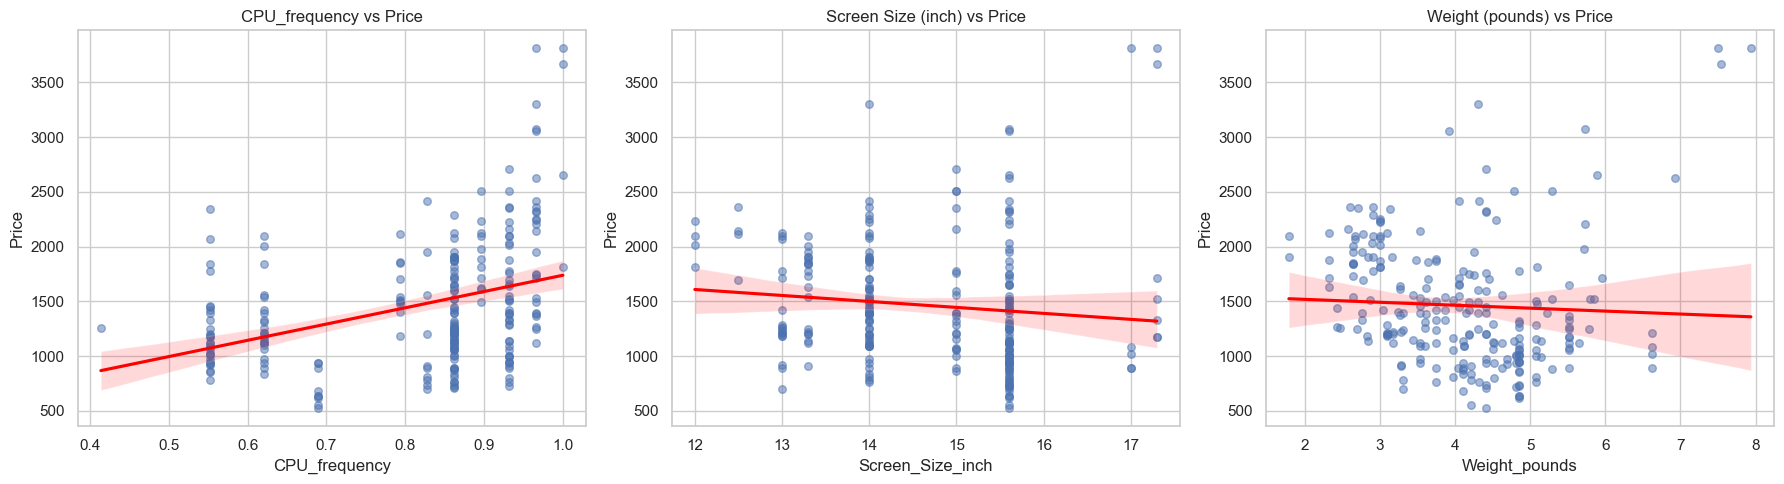

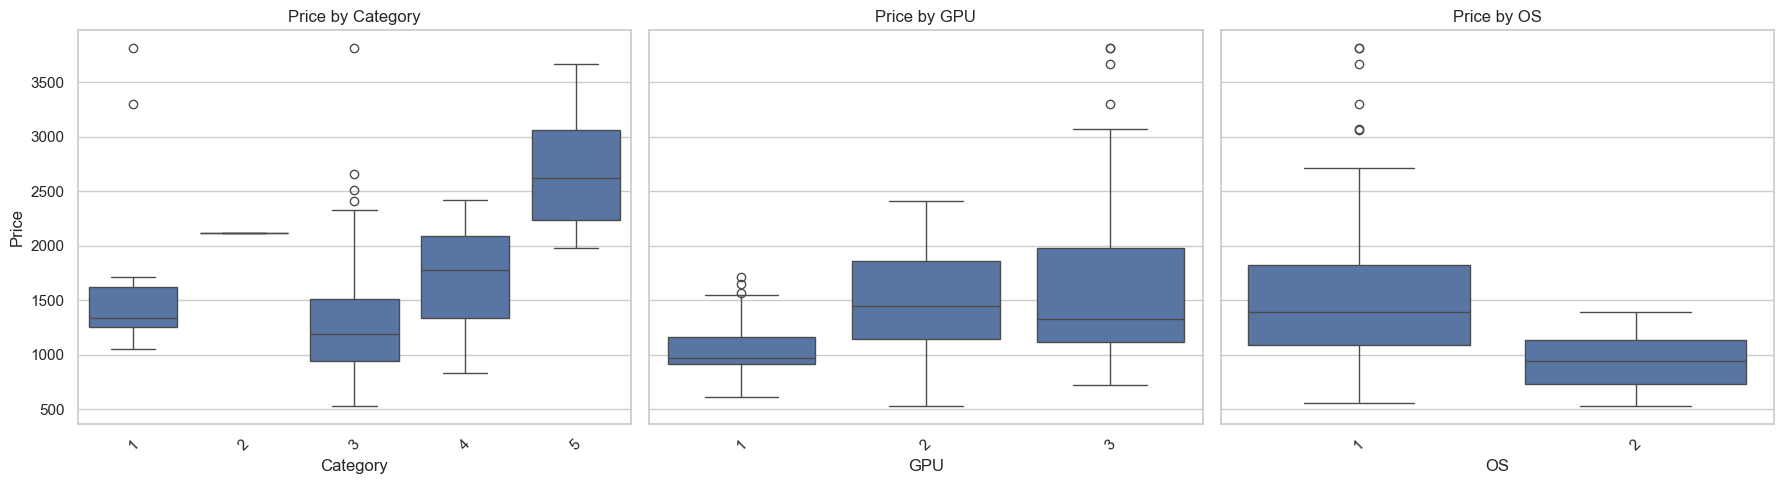

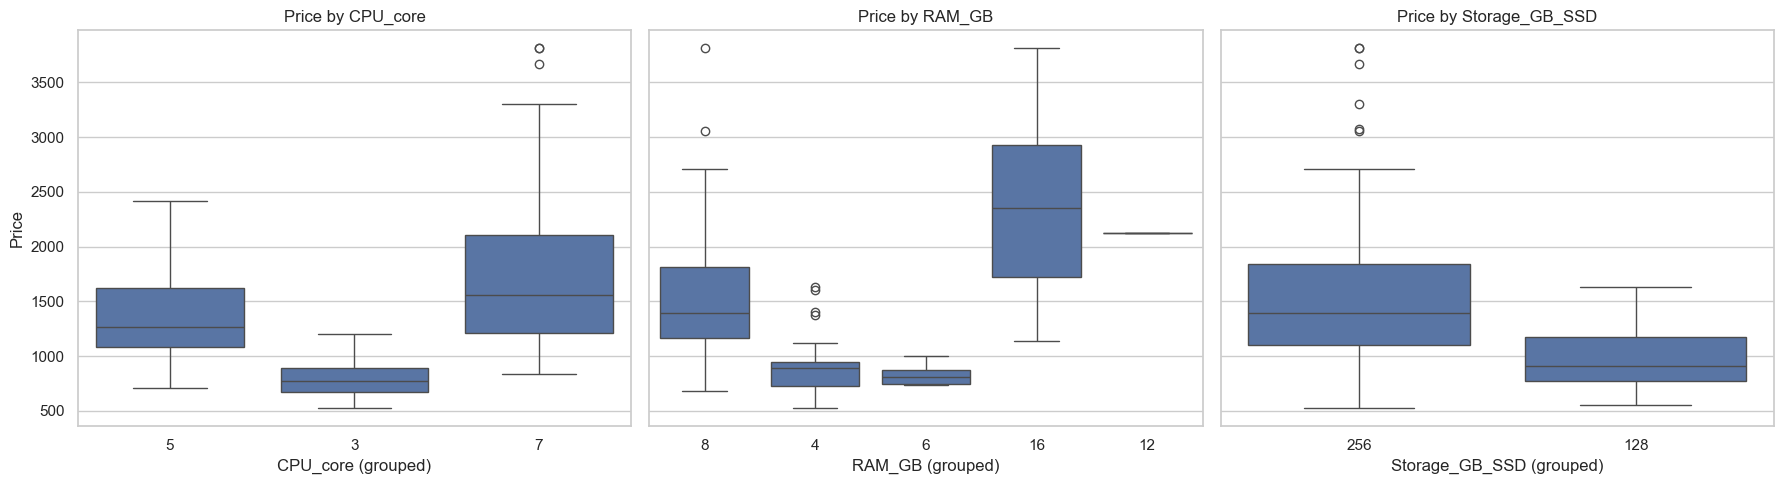

In [15]:
# Python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure numeric columns are numeric for plotting
numeric_cols = ["Price", "CPU_frequency", "Screen_Size_inch", "Weight_pounds", "CPU_core", "RAM_GB", "Storage_GB_SSD"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) Regression plots: CPU_frequency vs Price, Screen_Size_inch vs Price, Weight_pounds vs Price
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [("CPU_frequency", "Price"), ("Screen_Size_inch", "Price"), ("Weight_pounds", "Price")]
titles = ["CPU_frequency vs Price", "Screen Size (inch) vs Price", "Weight (pounds) vs Price"]

for ax, (xcol, ycol), title in zip(axes, pairs, titles):
    if xcol in df.columns and ycol in df.columns:
        sns.regplot(data=df, x=xcol, y=ycol, scatter_kws={"alpha": 0.5, "s": 30}, line_kws={"color": "red"}, ax=ax)
        ax.set_title(title)
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()

# 2) Box plots of Price by categorical and discrete attributes
# Category-like fields
cat_attrs = ["Category", "GPU", "OS"]
# Discrete numeric fields – treat as categorical bins on x-axis
disc_attrs = ["CPU_core", "RAM_GB", "Storage_GB_SSD"]

# Box plots for categorical attributes
n = sum(attr in df.columns for attr in cat_attrs)
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    if n == 1:
        axes = [axes]
    i = 0
    for attr in cat_attrs:
        if attr in df.columns and "Price" in df.columns:
            sns.boxplot(data=df, x=attr, y="Price", ax=axes[i])
            axes[i].set_title(f"Price by {attr}")
            axes[i].tick_params(axis='x', rotation=45)
            i += 1
    plt.tight_layout()
    plt.show()

# Box plots for discrete numeric attributes (cast to categorical for grouping)
m = sum(attr in df.columns for attr in disc_attrs)
if m > 0:
    fig, axes = plt.subplots(1, m, figsize=(6*m, 5), sharey=True)
    if m == 1:
        axes = [axes]
    j = 0
    for attr in disc_attrs:
        if attr in df.columns and "Price" in df.columns:
            sns.boxplot(data=df.assign(**{attr: df[attr].astype("Int64").astype(str)}), x=attr, y="Price", ax=axes[j])
            axes[j].set_title(f"Price by {attr}")
            axes[j].set_xlabel(f"{attr} (grouped)")
            axes[j].tick_params(axis='x', rotation=0)
            j += 1
    plt.tight_layout()
    plt.show()

Write a Python code for the following.
1. Evaluate the correlation value, pearson coefficient and p-values for all numerical attributes against the target attribute "Price".
2. Don't include the values evaluated for target variable against itself.
3. Print these values as a part of a single dataframe against each individual attribute.

In [16]:
# Python
import pandas as pd
import numpy as np
from scipy import stats

def pearson_against_target(df: pd.DataFrame, target: str = "Price") -> pd.DataFrame:
    # Keep only numeric columns
    num_df = df.select_dtypes(include=[np.number]).copy()
    if target not in num_df.columns:
        raise ValueError(f"Target '{target}' must be a numeric column in the DataFrame.")

    results = []
    y = pd.to_numeric(num_df[target], errors="coerce")

    for col in num_df.columns:
        if col == target:
            continue
        x = pd.to_numeric(num_df[col], errors="coerce")

        # Align non-missing pairs
        mask = x.notna() & y.notna()
        x_valid = x[mask]
        y_valid = y[mask]

        if len(x_valid) < 2:
            corr, pval = np.nan, np.nan
        else:
            corr, pval = stats.pearsonr(x_valid, y_valid)

        results.append({"attribute": col, "pearson_r": corr, "p_value": pval})

    out = pd.DataFrame(results).sort_values(by="attribute").reset_index(drop=True)
    return out

# Example usage (assumes df exists and has a numeric 'Price' column):
report = pearson_against_target(df, target="Price")
print(report)

           attribute  pearson_r       p_value
0           CPU_core   0.459398  7.912950e-14
1      CPU_frequency   0.366666  5.502463e-09
2           Category   0.286243  7.225696e-06
3                GPU   0.288298  6.166950e-06
4                 OS  -0.221730  5.696643e-04
5             RAM_GB   0.549297  3.681561e-20
6     Screen-Full_HD  -0.021075  7.463568e-01
7   Screen-IPS_panel   0.021075  7.463568e-01
8   Screen_Size_inch  -0.110644  8.853398e-02
9     Storage_GB_SSD   0.243421  1.489892e-04
10        Unnamed: 0   0.321933  3.851058e-07
11      Unnamed: 0.1   0.321933  3.851058e-07
12     Weight_pounds  -0.050312  4.397694e-01


Write a python code that performs the following actions.
1. Group the attributes "GPU", "CPU_core" and "Price", as available in a dataframe df
2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
3. Plot a pcolor plot for this pivot table.

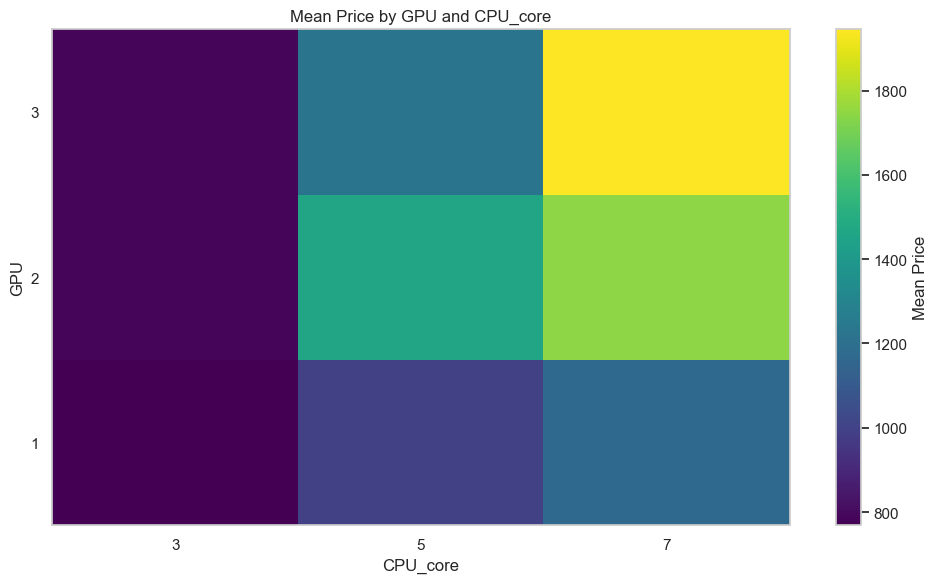

CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


In [17]:
# Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure numeric dtype for CPU_core and Price
df['CPU_core'] = pd.to_numeric(df['CPU_core'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# 1) Group GPU, CPU_core, Price (implicitly via pivot aggregation)
# 2) Pivot table: mean Price by GPU (rows) and CPU_core (columns)
pivot = pd.pivot_table(
    df,
    values='Price',
    index='GPU',
    columns='CPU_core',
    aggfunc='mean'
)

# 3) pcolor plot
fig, ax = plt.subplots(figsize=(10, 6))

# Replace inf with NaN to avoid plotting issues
Z = pivot.replace([np.inf, -np.inf], np.nan).values

# pcolor expects 2D array; use a colormap and show NaNs as masked
cmap = plt.cm.viridis
masked_Z = np.ma.masked_invalid(Z)
c = ax.pcolor(masked_Z, cmap=cmap)

# Ticks and labels aligned to cell centers
ax.set_xticks(np.arange(pivot.shape[1]) + 0.5)
ax.set_yticks(np.arange(pivot.shape[0]) + 0.5)
ax.set_xticklabels(pivot.columns.astype(str), rotation=0)
ax.set_yticklabels(pivot.index.astype(str))

ax.set_xlabel('CPU_core')
ax.set_ylabel('GPU')
ax.set_title('Mean Price by GPU and CPU_core')

fig.colorbar(c, ax=ax, label='Mean Price')

plt.tight_layout()
plt.show()

# Optional: inspect the pivot
print(pivot)

# Lab 4: Generative AI for Data Visualisation

This lab was not implemented on a Jupyter Notebok.

# Lab 5: Generative AI for Models Development

In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

Write a compact Python code that can perform the following tasks.
Read the CSV file, located on a given file path, into a pandas data frame, assuming that the first row of the file can be used as the headers for the data.

In [1]:
# Python
import pandas as pd

def read_csv_with_headers(path: str) -> pd.DataFrame:
    return pd.read_csv(path, header=0)

# Example:
# df = read_csv_with_headers("path/to/file.csv")
# print(df.head())

df = read_csv_with_headers("11_Generative_AI_laptop_pricing_dataset_mod2.csv")
print(df.head())

   Unnamed: 0.1  Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  \
0             0           0         Acer         4    2   1         5   
1             1           1         Dell         3    1   1         3   
2             2           2         Dell         3    1   1         7   
3             3           3         Dell         4    2   1         5   
4             4           4           HP         4    2   1         7   

   Screen_Size_inch  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pounds  \
0              14.0       0.551724       8             256        3.52800   
1              15.6       0.689655       4             256        4.85100   
2              15.6       0.931034       8             256        4.85100   
3              13.3       0.551724       8             128        2.69010   
4              15.6       0.620690       8             256        4.21155   

   Price Price-binned  Screen-Full_HD  Screen-IPS_panel  
0    978          Low               0   

Write a compact Python code that performs the following tasks.
1. Develops and trains a linear regression model that uses one attribute of a data frame as the source variable and another as a target variable.
2. Calculate and display the MSE and R^2 values for the trained model.

You can use this code to develop a linear regression model with the target variable as Price and the source variable as CPU_frequency.

In [2]:
# Python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def train_simple_linear(df: pd.DataFrame, feature: str, target: str):
    X = pd.to_numeric(df[feature], errors='coerce').to_frame()
    y = pd.to_numeric(df[target], errors='coerce')
    mask = X[feature].notna() & y.notna()
    X_train, X_test, y_train, y_test = train_test_split(X[mask], y[mask], test_size=0.2, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    preds = model.predict(X_test)
    mse, r2 = mean_squared_error(y_test, preds), r2_score(y_test, preds)
    print(f"MSE: {mse:.4f}, R^2: {r2:.4f}")
    return model, mse, r2

# Example:
# df = pd.read_csv("path/to/file.csv")
# model, mse, r2 = train_simple_linear(df, feature="CPU_frequency", target="Price")

model, mse, r2 = train_simple_linear(df, feature="CPU_frequency", target="Price")

MSE: 239035.9943, R^2: -0.0372


Write a very brief and compact Python code that performs the following tasks.
1. Develops and trains a linear regression model that uses some attributes of a data frame as the source variables and one of the attributes as a target variable.
2. Calculate and display the MSE and R^2 values for the trained model.

You can use the generated code and build a linear regression model for the data set that uses CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category and source variables and Price as the target variable

In [4]:
# Python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Assume df already loaded
features_num = ["CPU_frequency","RAM_GB","Storage_GB_SSD","CPU_core"]
features_cat = ["OS","GPU","Category"]
target = "Price"

# Coerce numeric, one-hot encode categoricals
X_num = df[features_num].apply(pd.to_numeric, errors='coerce')
X_cat = pd.get_dummies(df[features_cat].astype("category"), drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = pd.to_numeric(df[target], errors='coerce')

mask = X.notna().all(1) & y.notna()
Xtr, Xte, ytr, yte = train_test_split(X[mask], y[mask], test_size=0.2, random_state=42)

model = LinearRegression().fit(Xtr, ytr)
pred = model.predict(Xte)
mse, r2 = mean_squared_error(yte, pred), r2_score(yte, pred)
print(f"MSE: {mse:.4f}, R^2: {r2:.4f}")

MSE: 150698.4182, R^2: 0.3461


Write a very compact Python code that performs the following tasks.
1. Develops and trains multiple polynomial regression models, with orders 2, 3, and 5, that use one attribute of a data frame as the source variable and another as a target variable.
2. Calculate and display the MSE and R^2 values for the trained models.
3. Compare the performance of the models.

You can use the generated code with the source variable as CPU frequency and the target variable as Price.

In [5]:
# Python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = pd.to_numeric(df["CPU_frequency"], errors="coerce").to_frame()
y = pd.to_numeric(df["Price"], errors="coerce")
m = X.notna().all(1) & y.notna()
Xtr, Xte, ytr, yte = train_test_split(X[m], y[m], test_size=0.2, random_state=42)

orders = [2,3,5]
results = []
for d in orders:
    Xt = PolynomialFeatures(d, include_bias=False).fit_transform(Xtr)
    Xe = PolynomialFeatures(d, include_bias=False).fit(Xtr).transform(Xte)
    model = LinearRegression().fit(Xt, ytr)
    pred = model.predict(Xe)
    mse, r2 = mean_squared_error(yte, pred), r2_score(yte, pred)
    results.append((d, mse, r2))
    print(f"deg {d}: MSE={mse:.4f}, R^2={r2:.4f}")

best = min(results, key=lambda t: t[1])
print(f"Best by MSE: degree {best[0]}")

deg 2: MSE=196263.5615, R^2=0.1484
deg 3: MSE=205918.0302, R^2=0.1065
deg 5: MSE=207335.7036, R^2=0.1004
Best by MSE: degree 2


Write a very brief and compact Python code that performs the following tasks.
1. Create a pipeline that performs parameter scaling, Polynomial Feature generation, and Linear regression. Use the set of multiple features as before to create this pipeline.
2. Calculate and display the MSE and R^2 values for the trained model.

Consider the same set of attributes as used for multiple feature linear regression, which is CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category as source variables, and Price as the target variable.

In [6]:
# Python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

num = ["CPU_frequency","RAM_GB","Storage_GB_SSD","CPU_core"]
cat = ["OS","GPU","Category"]
y = pd.to_numeric(df["Price"], errors="coerce")
X = pd.concat([df[num].apply(pd.to_numeric, errors="coerce"), df[cat]], axis=1)
m = X[num].notna().all(1) & y.notna()
pre = ColumnTransformer([
    ("num", Pipeline([("sc", StandardScaler())]), num),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat)
])
pipe = Pipeline([("pre", pre), ("poly", PolynomialFeatures(degree=2, include_bias=False)), ("lr", LinearRegression())])
Xtr, Xte, ytr, yte = train_test_split(X[m], y[m], test_size=0.2, random_state=42)
pipe.fit(Xtr, ytr)
p = pipe.predict(Xte)
print(f"MSE: {mean_squared_error(yte,p):.4f}, R^2: {r2_score(yte,p):.4f}")

MSE: 246121.6412, R^2: -0.0679


Write a very brief nad compact Python code that performs the following tasks.
1. Use polynomial features for some of the attributes of a data frame.
2. Perform Grid search on a ridge regression model for a set of values of hyperparameter alpha and polynomial features as input.
3. Use cross-validation in the Grid search.
4. Evaluate the resulting model's MSE and R^2 values.

Make use of the following parametric values for this purpose:

Source Variables: CPU_frequency, RAM_GB, Storage_GB_SSD, CPU_core, OS, GPU and Category
Target Variable: Price
Set of values for alpha: 0.0001,0.001,0.01, 0.1, 1, 10
Cross Validation: 4-fold
Polynomial Feature order: 2

In [7]:
# Python
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

num = ["CPU_frequency","RAM_GB","Storage_GB_SSD","CPU_core"]
cat = ["OS","GPU","Category"]
X = pd.concat([df[num].apply(pd.to_numeric, errors="coerce"), df[cat]], axis=1)
y = pd.to_numeric(df["Price"], errors="coerce")
m = X[num].notna().all(1) & y.notna()
pre = ColumnTransformer([
    ("num", Pipeline([("sc", StandardScaler())]), num),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat)
])
pipe = Pipeline([("pre", pre), ("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge())])
param_grid = {"ridge__alpha": [0.0001,0.001,0.01,0.1,1,10]}
Xtr, Xte, ytr, yte = train_test_split(X[m], y[m], test_size=0.2, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=4, n_jobs=-1).fit(Xtr, ytr)
p = gs.predict(Xte)
print(f"Best alpha: {gs.best_params_['ridge__alpha']}, MSE: {mean_squared_error(yte,p):.4f}, R^2: {r2_score(yte,p):.4f}")

Best alpha: 10, MSE: 177882.5333, R^2: 0.2282


# Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


# Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
